# EJD-UMA-003 v7.1 -- Naive Bayes Federado con Variables Contextuales CRISC

**Ejercicio doctoral | Programa de Doctorado en Tecnologias Informaticas | Universidad de Malaga**

| Campo | Detalle |
|-------|----------|
| Codigo | EJD-UMA-003 |
| Version | 7.1 |
| Referencia | Continuacion de EJD-UMA-003 v6.0 — respuesta al pedido del Prof. Lopez Rubio |
| Autor | Edgar O. Herrera Logrono, M.Sc. Inteligencia Artificial, VIU Espana |
| Directores propuestos | Prof. Ezequiel Lopez Rubio y Prof. Juan Miguel Ortiz de Lazcano, UMA |
| Dataset | NSL-KDD (KDDTrain+.txt) |
| Fecha | Abril 2026 |

---

## Motivacion de esta version

La v6.0 demostro que la mezcla de distribuciones ponderada por entropia supera al baseline en los tres niveles de heterogeneidad evaluados. Al compartir ese resultado, el Prof. Lopez Rubio senalo algo preciso: hay que documentar que variables contextuales se proponen incorporar y pensar como aprovecharlas.

Esta version da ese paso. Incorpora cuatro variables del marco CRISC como pesos reales en el mecanismo de agregacion federada, a traves de un Indice de Confianza Contextual (ICC):

| Variable | Nivel CRISC | Como afecta el peso |
|----------|------------|--------------------|
| Madurez CMM | Observable | Mayor madurez, mayor confianza en el modelo local |
| Severidad CVSS | Observable | Mayor severidad, menor confianza (datos potencialmente comprometidos) |
| Eficacia de KCI | Estimable proxy | KCI debil indica entorno inestable, menor peso |
| Desviacion de KRI | Estimable proxy | KRI fuera de umbral indica riesgo operacional elevado, menor peso |

Las variables latentes (Cultura del Riesgo y Riesgo Inherente del Sector) y el FCOR no se incorporan como pesos directos. Se declaran como limitacion explicita en las conclusiones.

## Hipotesis de esta version

Ponderar los nodos por su perfil de riesgo organizacional — no solo por la entropia de su distribucion local — deberia producir un modelo global mas preciso, porque incorpora informacion sobre la confiabilidad del aprendizaje local de cada nodo. Sin embargo, el ICC y la entropia capturan dimensiones distintas: un nodo puede ser maduro organizacionalmente pero poco diverso en datos. El criterio combinado ICC x Entropia integra ambas dimensiones.

## Modelos comparados

| Modelo | Criterio de peso | Origen |
|--------|-----------------|--------|
| NB Variables Contextuales | ICC (CMM + CVSS + KCI + KRI) | Nuevo en v7.x |
| NB Mezcla Combinada | ICC x Entropia de Shannon | Nuevo en v7.x |
| NB Mezcla Entropia | Entropia de Shannon | Referencia desde v6.0 |
| NB Baseline | Promedio de parametros (FedAvg) | Referencia desde v5.0 |
| NB Centralizado | Sin restriccion de privacidad | Cota superior |

In [29]:
# ==============================================================
# PARAMETROS CONFIGURABLES
# ==============================================================
# Todos los valores que afectan el experimento estan aqui.
# Los valores de las variables contextuales simulan perfiles
# representativos de cada sector en infraestructura critica real.
#
# CMM (Madurez 0-5):
#   5 = procesos optimizados y auditados regularmente
#   3 = procesos definidos pero no sistematizados
#   2 = procesos ad hoc, alta variabilidad operacional
#
# CVSS (Severidad promedio 0-10 en activos criticos):
#   Se invierte al calcular el ICC: CVSS alto reduce el peso del nodo
#
# KCI (Eficacia de controles 0-1):
#   1.0 = controles funcionando al nivel esperado
#   0.5 = controles con brechas significativas detectadas
#
# KRI (Desviacion de indicadores de riesgo 0-1):
#   Se invierte al calcular el ICC: KRI alto reduce el peso del nodo
#   0.0 = nodo opera dentro de tolerancia al riesgo
#   0.8 = nodo frecuentemente fuera de tolerancia
#
# PESOS_VC: importancia relativa de cada variable en el ICC
#   Deben sumar 1.0

SEMILLA         = 42
TEST_SIZE       = 0.3
ALPHA_DIRICHLET = 0.1

NODOS = ['Financiero', 'Salud', 'Gobierno']

VARIABLES_CONTEXTUALES = {
    'Financiero': {
        'CMM':  4.0,   # Alta madurez: sector fuertemente regulado (Basilea, PCI-DSS)
        'CVSS': 6.5,   # Severidad media-alta: blanco frecuente de APT financiero
        'KCI':  0.78,  # Controles razonablemente efectivos
        'KRI':  0.22   # Opera mayormente dentro de tolerancia
    },
    'Salud': {
        'CMM':  3.0,   # Madurez media: regulacion sanitaria variable segun pais
        'CVSS': 4.0,   # Severidad media: activos criticos pero menor exposicion
        'KCI':  0.82,  # Controles bien implementados en su dominio
        'KRI':  0.31   # Algunas desviaciones pero dentro de rango aceptable
    },
    'Gobierno': {
        'CMM':  2.0,   # Madurez baja: procesos ad hoc, alta rotacion de personal
        'CVSS': 7.5,   # Severidad alta: infraestructura legacy con vulnerabilidades acumuladas
        'KCI':  0.51,  # Controles con brechas significativas
        'KRI':  0.64   # Opera frecuentemente fuera de tolerancia al riesgo
    }
}

PESOS_VC = {
    'CMM':  0.30,
    'CVSS': 0.25,
    'KCI':  0.25,
    'KRI':  0.20
}

URL_DATASET = 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt'

COLORES_NODO = {'Financiero': '#2196F3', 'Salud': '#4CAF50', 'Gobierno': '#FF9800'}
COLORES_MODELO = {
    'NB Variables Contextuales': '#E91E63',
    'NB Mezcla Combinada':       '#9C27B0',
    'NB Mezcla Entropia':        '#673AB7',
    'NB Baseline':               '#F44336',
    'NB Centralizado':           '#00BCD4'
}

print('[ OK ] Parametros configurables cargados')
print()
print(f'  {"Nodo":<12} {"CMM":>6} {"CVSS":>6} {"KCI":>6} {"KRI":>6}')
print('  ' + '-' * 36)
for nodo, vc in VARIABLES_CONTEXTUALES.items():
    print(f'  {nodo:<12} {vc["CMM"]:>6.1f} {vc["CVSS"]:>6.1f} {vc["KCI"]:>6.2f} {vc["KRI"]:>6.2f}')

[ OK ] Parametros configurables cargados

  Nodo            CMM   CVSS    KCI    KRI
  ------------------------------------
  Financiero      4.0    6.5   0.78   0.22
  Salud           3.0    4.0   0.82   0.31
  Gobierno        2.0    7.5   0.51   0.64


In [30]:
# ==============================================================
# SECCION 1 -- Preparacion del entorno
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import entropy
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(SEMILLA)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11
})

print('[ OK ] Entorno listo')

[ OK ] Entorno listo


In [31]:
# ==============================================================
# SECCION 2 -- Carga y preprocesamiento del dataset NSL-KDD
# ==============================================================

COLUMNAS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

MAPA_CLASES = {
    'normal': 'normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R',
    'rootkit': 'U2R', 'ps': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R', 'worm': 'U2R'
}

df = pd.read_csv(URL_DATASET, names=COLUMNAS, header=None)
df['clase'] = df['label'].map(MAPA_CLASES).fillna('Other')
df = df[df['clase'] != 'Other'].copy()

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

le_clase       = LabelEncoder()
df['clase_id'] = le_clase.fit_transform(df['clase'])
clases         = le_clase.classes_
n_clases       = len(clases)

RASGOS   = [c for c in COLUMNAS if c not in ['label', 'difficulty', 'clase', 'clase_id']]
X        = df[RASGOS].values.astype(float)
y        = df['clase_id'].values
n_rasgos = X.shape[1]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y
)

# Prior global: distribucion real del conjunto de prueba.
# Elimina el sesgo de composicion de cada nodo — leccion aprendida en v5.0.
conteo_global    = np.bincount(y_test, minlength=n_clases).astype(float)
PRIOR_GLOBAL     = conteo_global / conteo_global.sum()
LOG_PRIOR_GLOBAL = np.log(np.clip(PRIOR_GLOBAL, 1e-10, None))

print(f'[ OK ] Datos cargados: {len(df):,} registros')
print(f'       Clases         : {list(clases)}')
print(f'       Rasgos         : {n_rasgos}')
print(f'       Train / Test   : {len(X_train):,} / {len(X_test):,}')

[ OK ] Datos cargados: 125,973 registros
       Clases         : ['DoS', 'Probe', 'R2L', 'U2R', 'normal']
       Rasgos         : 41
       Train / Test   : 88,181 / 37,792


In [32]:
# ==============================================================
# SECCION 3 -- Calculo del Indice de Confianza Contextual (ICC)
# ==============================================================
# El ICC combina las cuatro variables CRISC en un indice unico
# por nodo. Cada variable se normaliza al rango [0,1] y las
# que representan riesgo (CVSS, KRI) se invierten:
# mayor riesgo = menor confianza = menor peso en la mezcla.
#
# ICC(k) = w_CMM  * CMM_norm(k)
#         + w_CVSS * (1 - CVSS_norm(k))
#         + w_KCI  * KCI(k)
#         + w_KRI  * (1 - KRI(k))

def calcular_icc(variables_contextuales, pesos_vc):
    """Calcula el Indice de Confianza Contextual para cada nodo.
    Un ICC alto indica nodo confiable. Un ICC bajo indica nodo
    cuyo modelo local debe recibir menor peso en la mezcla.
    """
    icc = {}
    for nodo, vc in variables_contextuales.items():
        cmm_norm  = vc['CMM']  / 5.0
        cvss_norm = vc['CVSS'] / 10.0
        kci_norm  = vc['KCI']
        kri_norm  = vc['KRI']
        icc[nodo] = (
            pesos_vc['CMM']  * cmm_norm        +
            pesos_vc['CVSS'] * (1 - cvss_norm) +
            pesos_vc['KCI']  * kci_norm        +
            pesos_vc['KRI']  * (1 - kri_norm)
        )
    return icc


icc = calcular_icc(VARIABLES_CONTEXTUALES, PESOS_VC)

print('[ OK ] Indice de Confianza Contextual (ICC) calculado')
print()
print(f'  {"Nodo":<12} {"CMM":>6} {"CVSS":>6} {"KCI":>6} {"KRI":>6} {"ICC":>8}')
print('  ' + '-' * 44)
for nodo, vc in VARIABLES_CONTEXTUALES.items():
    print(f'  {nodo:<12} {vc["CMM"]:>6.1f} {vc["CVSS"]:>6.1f} '
          f'{vc["KCI"]:>6.2f} {vc["KRI"]:>6.2f} {icc[nodo]:>8.4f}')
print()
mejor_nodo = max(icc, key=icc.get)
peor_nodo  = min(icc, key=icc.get)
print(f'  Mayor ICC: {mejor_nodo} ({icc[mejor_nodo]:.4f})')
print(f'  Menor ICC: {peor_nodo}  ({icc[peor_nodo]:.4f})')

[ OK ] Indice de Confianza Contextual (ICC) calculado

  Nodo            CMM   CVSS    KCI    KRI      ICC
  --------------------------------------------
  Financiero      4.0    6.5   0.78   0.22   0.6785
  Salud           3.0    4.0   0.82   0.31   0.6730
  Gobierno        2.0    7.5   0.51   0.64   0.3820

  Mayor ICC: Financiero (0.6785)
  Menor ICC: Gobierno  (0.3820)


In [33]:
# ==============================================================
# SECCION 4 -- Particion Dirichlet y entrenamiento local
# ==============================================================
# Alpha=0.1 reproduce la condicion de heterogeneidad alta de v6.0
# (JS medio ~0.65), que es donde la mezcla muestra mayor ventaja.
# Los resultados son directamente comparables con versiones anteriores.

def particion_dirichlet(X, y, n_nodos, alpha, semilla):
    """Particion non-IID estandar segun Li et al. (2022, NeurIPS)."""
    rng           = np.random.default_rng(semilla)
    clases_unicas = np.unique(y)
    indices_nodo  = [[] for _ in range(n_nodos)]
    for clase in clases_unicas:
        idx    = np.where(y == clase)[0]
        rng.shuffle(idx)
        props  = rng.dirichlet([alpha] * n_nodos)
        cortes = (props * len(idx)).astype(int)
        cortes[-1] = len(idx) - cortes[:-1].sum()
        cortes = np.maximum(cortes, 1)
        inicio = 0
        for i, n in enumerate(cortes):
            indices_nodo[i].extend(idx[inicio:inicio + n].tolist())
            inicio += n
    return [(X[idx], y[idx]) for idx in indices_nodo]


particiones      = particion_dirichlet(X_train, y_train, len(NODOS), ALPHA_DIRICHLET, SEMILLA)
datos_nodos      = dict(zip(NODOS, particiones))
modelos_locales  = {}
entropias_locales = {}

print(f'[ OK ] Particion Dirichlet aplicada (alpha={ALPHA_DIRICHLET})')
print()
for nodo, (X_n, y_n) in datos_nodos.items():
    modelo = GaussianNB()
    modelo.fit(X_n, y_n)
    modelos_locales[nodo] = modelo
    conteo = np.bincount(y_n, minlength=n_clases).astype(float)
    dist   = conteo / conteo.sum()
    entropias_locales[nodo] = entropy(dist + 1e-10)
    clase_dom = clases[np.argmax(conteo)]
    print(f'  Nodo {nodo}: {len(y_n):,} muestras | '
          f'clase dominante: {clase_dom} ({conteo.max()/conteo.sum():.1%}) | '
          f'entropia: {entropias_locales[nodo]:.3f}')

print()
print('[ OK ] Entrenamiento local completado')

[ OK ] Particion Dirichlet aplicada (alpha=0.1)

  Nodo Financiero: 46,770 muestras | clase dominante: normal (99.7%) | entropia: 0.021
  Nodo Salud: 8,923 muestras | clase dominante: Probe (89.3%) | entropia: 0.407
  Nodo Gobierno: 32,488 muestras | clase dominante: DoS (98.1%) | entropia: 0.106

[ OK ] Entrenamiento local completado


In [34]:
# ==============================================================
# SECCION 5 -- Funciones de agregacion federada
# ==============================================================
# Se mantiene la formula de mezcla de gaussianas de v6.0
# (Roberts, 1962), ahora con tres criterios de ponderacion.

def agregar_nb(modelos, pesos, n_clases, n_rasgos, log_prior, modo='mezcla'):
    """Agrega distribuciones condicionales P(X|clase) con prior global.
    modo='mezcla'   : mezcla de gaussianas, preserva heterogeneidad
    modo='promedio' : promedio de parametros, baseline FedAvg
    """
    pesos_norm = np.array(pesos) / np.sum(pesos)
    mu_fed     = np.zeros((n_clases, n_rasgos))
    var_fed    = np.zeros((n_clases, n_rasgos))
    for modelo, w in zip(modelos, pesos_norm):
        for j, clase_id in enumerate(modelo.classes_):
            mu_k  = modelo.theta_[j]
            var_k = modelo.var_[j]
            if modo == 'mezcla':
                mu_fed[clase_id]  += w * mu_k
                var_fed[clase_id] += w * (var_k + mu_k ** 2)
            else:
                mu_fed[clase_id]  += w * mu_k
                var_fed[clase_id] += w * var_k
    if modo == 'mezcla':
        var_fed = var_fed - mu_fed ** 2
    var_fed = np.clip(var_fed, 1e-9, None)
    return mu_fed, var_fed, log_prior


def predecir_nb(X, mu, var, log_prior):
    """Clasificacion por log-posterior gaussiano.
    Operando en escala logaritmica se evita underflow numerico.
    """
    lp = np.zeros((X.shape[0], mu.shape[0]))
    for c in range(mu.shape[0]):
        lp[:, c] = log_prior[c] - 0.5 * np.sum(
            np.log(2 * np.pi * var[c]) + (X - mu[c]) ** 2 / var[c],
            axis=1
        )
    return np.argmax(lp, axis=1)


print('[ OK ] Funciones de agregacion y prediccion definidas')

[ OK ] Funciones de agregacion y prediccion definidas


In [35]:
# ==============================================================
# SECCION 6 -- Construccion de los modelos federados
# ==============================================================
# Tres criterios de ponderacion para comparar:
#
# ICC solo:    pondera por confianza organizacional CRISC
# Entropia:    pondera por diversidad de datos local (referencia v6.0)
# Combinado:   ICC x Entropia — nodo que es confiable Y diverso
#              recibe el mayor peso. Integra ambas dimensiones.

lista_modelos    = [modelos_locales[n] for n in NODOS]
pesos_icc        = [icc[n] for n in NODOS]
pesos_entropia   = [entropias_locales[n] for n in NODOS]
pesos_combinados = [icc[n] * entropias_locales[n] for n in NODOS]
pesos_tamano     = [len(datos_nodos[n][0]) for n in NODOS]

mu_vc,   var_vc,   _ = agregar_nb(lista_modelos, pesos_icc,        n_clases, n_rasgos, LOG_PRIOR_GLOBAL)
mu_comb, var_comb, _ = agregar_nb(lista_modelos, pesos_combinados, n_clases, n_rasgos, LOG_PRIOR_GLOBAL)
mu_entr, var_entr, _ = agregar_nb(lista_modelos, pesos_entropia,   n_clases, n_rasgos, LOG_PRIOR_GLOBAL)
mu_bl,   var_bl,   _ = agregar_nb(lista_modelos, pesos_tamano,     n_clases, n_rasgos, LOG_PRIOR_GLOBAL,
                                   modo='promedio')

modelo_central = GaussianNB()
modelo_central.fit(X_train, y_train)

def normalizar(pesos):
    total = sum(pesos)
    return [p / total for p in pesos]

print('[ OK ] Modelos federados construidos')
print()
print(f'  {"Nodo":<12} {"Peso ICC":>10} {"Peso Entr":>10} {"Peso Comb":>10}')
print('  ' + '-' * 44)
for nodo, w_icc, w_entr, w_comb in zip(
    NODOS,
    normalizar(pesos_icc),
    normalizar(pesos_entropia),
    normalizar(pesos_combinados)
):
    print(f'  {nodo:<12} {w_icc:>10.3f} {w_entr:>10.3f} {w_comb:>10.3f}')

[ OK ] Modelos federados construidos

  Nodo           Peso ICC  Peso Entr  Peso Comb
  --------------------------------------------
  Financiero        0.391      0.040      0.044
  Salud             0.388      0.762      0.833
  Gobierno          0.220      0.199      0.123


In [36]:
# ==============================================================
# SECCION 7 -- Evaluacion comparativa
# ==============================================================
# F1-macro es la metrica principal: le da el mismo peso a clases
# raras (U2R, R2L) que a las frecuentes. En infraestructura critica
# las clases raras son las mas peligrosas.

resultados = {}

def evaluar(nombre, y_pred):
    resultados[nombre] = {
        'accuracy':    accuracy_score(y_test, y_pred),
        'f1_macro':    f1_score(y_test, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_clase':    f1_score(y_test, y_pred, average=None,       zero_division=0),
        'pred':        y_pred
    }

evaluar('NB Variables Contextuales', predecir_nb(X_test, mu_vc,   var_vc,   LOG_PRIOR_GLOBAL))
evaluar('NB Mezcla Combinada',       predecir_nb(X_test, mu_comb, var_comb, LOG_PRIOR_GLOBAL))
evaluar('NB Mezcla Entropia',        predecir_nb(X_test, mu_entr, var_entr, LOG_PRIOR_GLOBAL))
evaluar('NB Baseline',               predecir_nb(X_test, mu_bl,   var_bl,   LOG_PRIOR_GLOBAL))
evaluar('NB Centralizado',           modelo_central.predict(X_test))
for nodo in NODOS:
    evaluar(f'NB Local {nodo}', modelos_locales[nodo].predict(X_test))

print(f'{"Modelo":<28} {"Accuracy":>10} {"F1-macro":>10} {"F1-weighted":>12}')
print('-' * 62)
for nombre, m in resultados.items():
    print(f'{nombre:<28} {m["accuracy"]:>10.4f} {m["f1_macro"]:>10.4f} {m["f1_weighted"]:>12.4f}')
print()
print('[ OK ] Evaluacion completada')

Modelo                         Accuracy   F1-macro  F1-weighted
--------------------------------------------------------------
NB Variables Contextuales        0.4690     0.3436       0.3437
NB Mezcla Combinada              0.5608     0.3922       0.5221
NB Mezcla Entropia               0.5506     0.3938       0.5071
NB Baseline                      0.4822     0.3740       0.3573
NB Centralizado                  0.4778     0.3307       0.3799
NB Local Financiero              0.5377     0.4050       0.5026
NB Local Salud                   0.4353     0.2754       0.2979
NB Local Gobierno                0.5801     0.3463       0.5821

[ OK ] Evaluacion completada


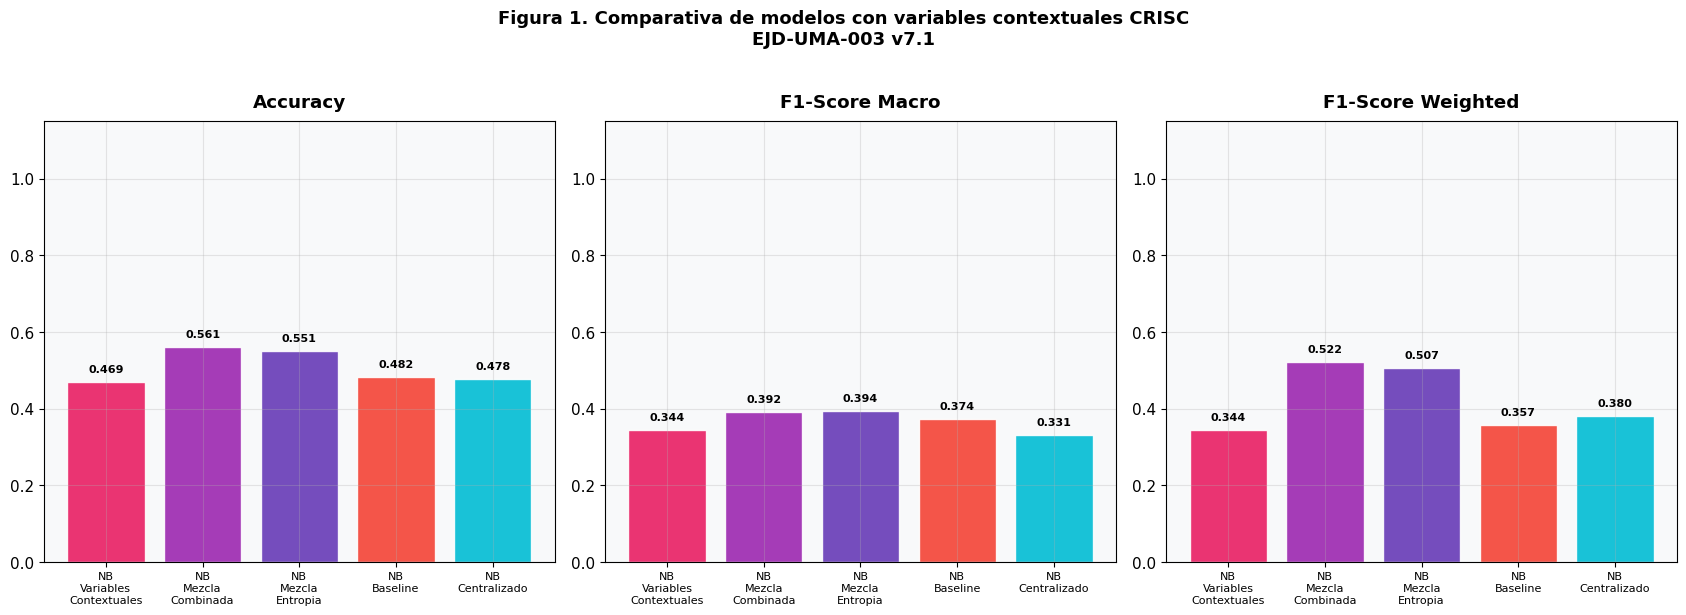

[ OK ] Figura 1 generada


In [37]:
# ==============================================================
# SECCION 8 -- Figura 1: Comparativa de modelos principales
# ==============================================================

modelos_principales = [
    'NB Variables Contextuales', 'NB Mezcla Combinada',
    'NB Mezcla Entropia', 'NB Baseline', 'NB Centralizado'
]
colores_barras = [COLORES_MODELO[m] for m in modelos_principales]

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Figura 1. Comparativa de modelos con variables contextuales CRISC\nEJD-UMA-003 v7.1',
             fontsize=13, fontweight='bold', y=1.02)

for ax, metrica, titulo in zip(
    axes,
    ['accuracy', 'f1_macro', 'f1_weighted'],
    ['Accuracy', 'F1-Score Macro', 'F1-Score Weighted']
):
    valores = [resultados[m][metrica] for m in modelos_principales]
    barras  = ax.bar(range(len(modelos_principales)), valores,
                     color=colores_barras, edgecolor='white', alpha=0.9)
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_xticks(range(len(modelos_principales)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in modelos_principales], fontsize=8)
    ax.set_ylim(0, 1.15)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('EJD_UMA_003_v71_figura1.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 1 generada')

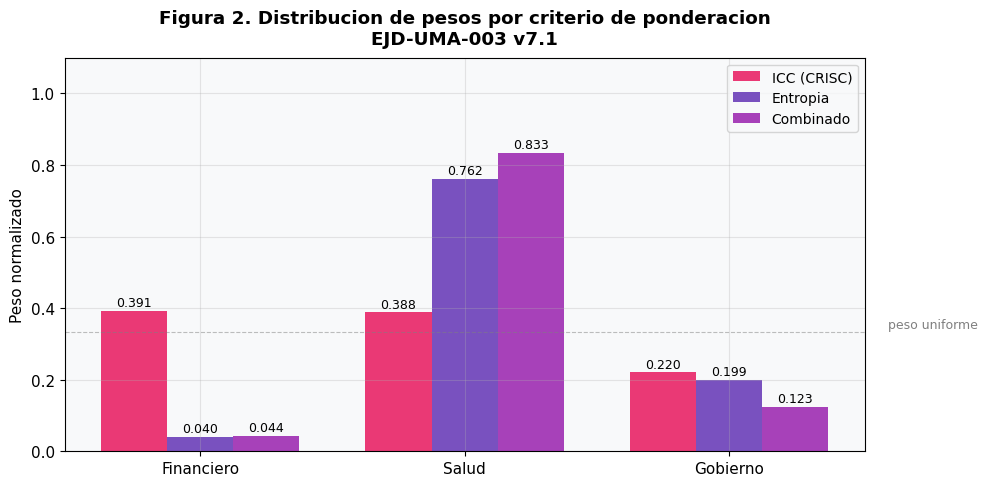

[ OK ] Figura 2 generada


In [38]:
# ==============================================================
# SECCION 9 -- Figura 2: Distribucion de pesos por criterio
# ==============================================================
# Hace visible como cambia el peso de cada nodo segun el criterio.
# La diferencia entre ICC y entropia en el nodo Financiero
# revela la tension central del ejercicio.

criterios           = ['ICC (CRISC)', 'Entropia', 'Combinado']
pesos_normalizados  = [
    normalizar(pesos_icc),
    normalizar(pesos_entropia),
    normalizar(pesos_combinados)
]
colores_criterios = ['#E91E63', '#673AB7', '#9C27B0']

x     = np.arange(len(NODOS))
ancho = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (criterio, pesos, color) in enumerate(zip(criterios, pesos_normalizados, colores_criterios)):
    offset = (i - 1) * ancho
    bars = ax.bar(x + offset, pesos, ancho, label=criterio, color=color, alpha=0.88)
    for b, v in zip(bars, pesos):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Figura 2. Distribucion de pesos por criterio de ponderacion\nEJD-UMA-003 v7.1',
             fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(NODOS, fontsize=11)
ax.set_ylabel('Peso normalizado')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.axhline(1/3, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(2.6, 1/3 + 0.01, 'peso uniforme', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('EJD_UMA_003_v71_figura2.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 2 generada')

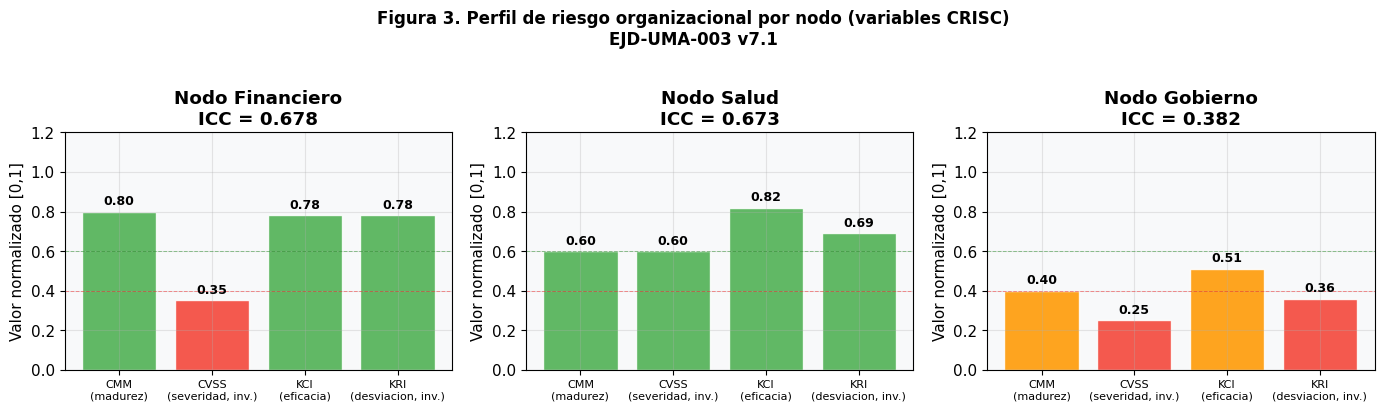

[ OK ] Figura 3 generada


In [39]:
# ==============================================================
# SECCION 10 -- Figura 3: Perfil de riesgo organizacional
# ==============================================================
# Muestra las cuatro variables CRISC de cada nodo normalizadas.
# Verde = dentro de rango aceptable, naranja = alerta, rojo = problema.
# Justifica visualmente por que el Gobierno recibe el menor peso.

variables_nombres = ['CMM\n(madurez)', 'CVSS\n(severidad, inv.)', 'KCI\n(eficacia)', 'KRI\n(desviacion, inv.)']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figura 3. Perfil de riesgo organizacional por nodo (variables CRISC)\nEJD-UMA-003 v7.1',
             fontsize=12, fontweight='bold', y=1.02)

for ax, nodo in zip(axes, NODOS):
    vc = VARIABLES_CONTEXTUALES[nodo]
    valores_norm = [
        vc['CMM']  / 5.0,
        1 - vc['CVSS'] / 10.0,
        vc['KCI'],
        1 - vc['KRI']
    ]
    colores_barra = [
        '#4CAF50' if v >= 0.6 else '#FF9800' if v >= 0.4 else '#F44336'
        for v in valores_norm
    ]
    barras = ax.bar(range(4), valores_norm, color=colores_barra, alpha=0.88, edgecolor='white')
    ax.set_title(f'Nodo {nodo}\nICC = {icc[nodo]:.3f}', fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xticklabels(variables_nombres, fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Valor normalizado [0,1]')
    ax.axhline(0.6, color='green', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.axhline(0.4, color='red',   linewidth=0.7, linestyle='--', alpha=0.4)
    for b, v in zip(barras, valores_norm):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('EJD_UMA_003_v71_figura3.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 3 generada')

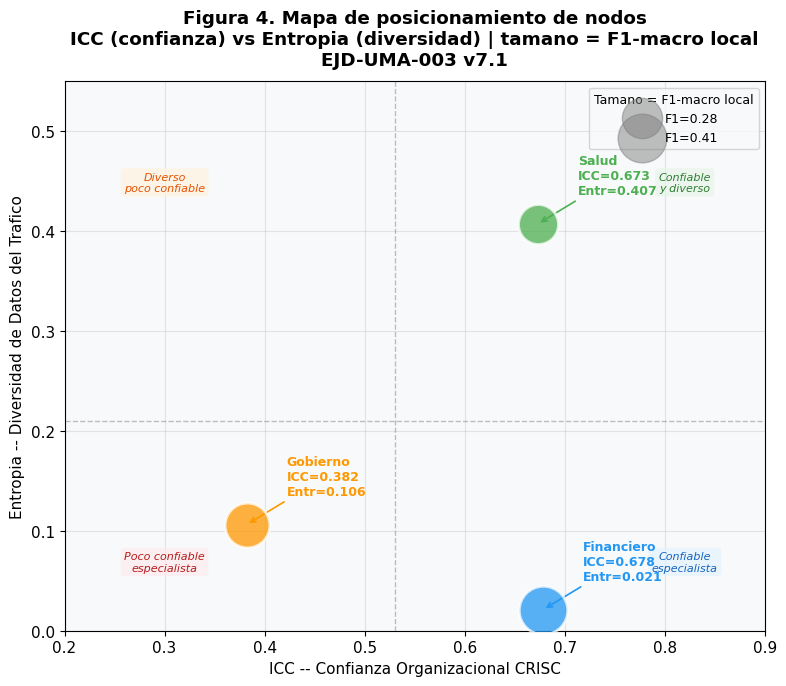

[ OK ] Figura 4 generada


In [40]:
# ==============================================================
# SECCION 11 -- Figura 4: Mapa de posicionamiento de nodos
# ==============================================================
# Muestra la tension entre ICC (confianza organizacional CRISC)
# y entropia (diversidad de datos del trafico de red).
#
# Cada nodo cae en uno de cuatro cuadrantes:
#   Confiable y diverso     -> peso combinado alto (cuadrante ideal)
#   Confiable, especialista -> ICC alto, entropia baja (Financiero)
#   Diverso, poco confiable -> ICC bajo, entropia alta
#   Poco confiable/diverso  -> peso bajo en ambos criterios (Gobierno)
#
# Esta figura es el hallazgo central de v7.x: ICC y entropia capturan
# dimensiones distintas que el criterio combinado integra.

fig, ax = plt.subplots(figsize=(8, 7))

# Cuadrantes
icc_mid  = 0.53
entr_mid = 0.21

ax.axvline(icc_mid,  color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axhline(entr_mid, color='gray', linewidth=1, linestyle='--', alpha=0.5)

# Etiquetas de cuadrantes
ax.text(0.82, 0.44, 'Confiable\ny diverso', fontsize=8, color='#2e7d32',
        ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f5e9', alpha=0.7, edgecolor='none'))
ax.text(0.30, 0.44, 'Diverso\npoco confiable', fontsize=8, color='#e65100',
        ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', alpha=0.7, edgecolor='none'))
ax.text(0.82, 0.06, 'Confiable\nespecialista', fontsize=8, color='#1565c0',
        ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#e3f2fd', alpha=0.7, edgecolor='none'))
ax.text(0.30, 0.06, 'Poco confiable\nespecialista', fontsize=8, color='#b71c1c',
        ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffebee', alpha=0.7, edgecolor='none'))

# Nodos: tamano proporcional al F1-macro local
f1_locales_plot = {
    'Financiero': resultados['NB Local Financiero']['f1_macro'],
    'Salud':      resultados['NB Local Salud']['f1_macro'],
    'Gobierno':   resultados['NB Local Gobierno']['f1_macro']
}

for nodo in NODOS:
    x_pos  = icc[nodo]
    y_pos  = entropias_locales[nodo]
    size   = f1_locales_plot[nodo] * 3000
    color  = COLORES_NODO[nodo]
    ax.scatter(x_pos, y_pos, s=size, color=color, alpha=0.75,
               edgecolors='white', linewidths=2, zorder=5)
    ax.annotate(
        f'{nodo}\nICC={x_pos:.3f}\nEntr={y_pos:.3f}',
        xy=(x_pos, y_pos),
        xytext=(x_pos + 0.04, y_pos + 0.03),
        fontsize=9, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.2)
    )

ax.set_xlabel('ICC -- Confianza Organizacional CRISC', fontsize=11)
ax.set_ylabel('Entropia -- Diversidad de Datos del Trafico', fontsize=11)
ax.set_title('Figura 4. Mapa de posicionamiento de nodos\n'
             'ICC (confianza) vs Entropia (diversidad) | tamano = F1-macro local\n'
             'EJD-UMA-003 v7.1',
             fontweight='bold', pad=12)
ax.set_xlim(0.2, 0.9)
ax.set_ylim(0.0, 0.55)

# Leyenda de tamano
for f1_ref, label in [(0.28, 'F1=0.28'), (0.41, 'F1=0.41')]:
    ax.scatter([], [], s=f1_ref * 3000, color='gray', alpha=0.5, label=label)
ax.legend(title='Tamano = F1-macro local', fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig('EJD_UMA_003_v71_figura4.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 4 generada')

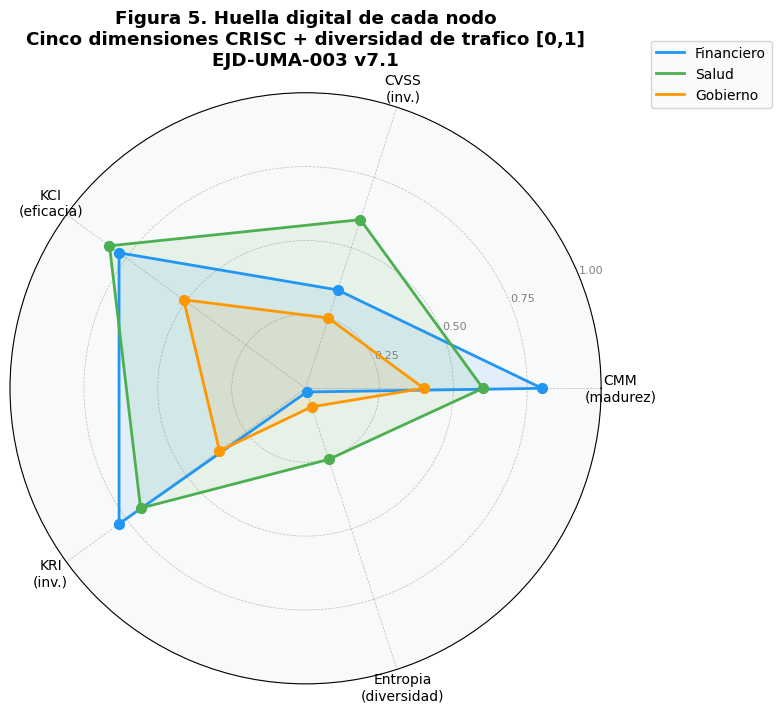

[ OK ] Figura 5 generada


In [41]:
# ==============================================================
# SECCION 12 -- Figura 5: Huella digital por nodo (radar)
# ==============================================================
# Muestra las cinco dimensiones de cada nodo en un unico grafico:
# cuatro variables CRISC normalizadas mas la entropia del trafico.
#
# Es el ADN de cada nodo: permite ver de un vistazo por que
# Salud es el unico nodo equilibrado en todas las dimensiones,
# y por que Gobierno concentra las brechas mas criticas.

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

dimensiones    = ['CMM\n(madurez)', 'CVSS\n(inv.)', 'KCI\n(eficacia)', 'KRI\n(inv.)', 'Entropia\n(diversidad)']
n_dim          = len(dimensiones)
angulos        = np.linspace(0, 2 * np.pi, n_dim, endpoint=False).tolist()
angulos       += angulos[:1]  # cerrar el poligono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for nodo in NODOS:
    vc = VARIABLES_CONTEXTUALES[nodo]
    # Entropia normalizada al rango [0,1] respecto al maximo teorico (log5 ~1.61)
    entr_norm = entropias_locales[nodo] / np.log(n_clases)
    valores = [
        vc['CMM']  / 5.0,
        1 - vc['CVSS'] / 10.0,
        vc['KCI'],
        1 - vc['KRI'],
        entr_norm
    ]
    valores += valores[:1]  # cerrar el poligono
    color = COLORES_NODO[nodo]
    ax.plot(angulos, valores, linewidth=2, linestyle='solid', color=color, label=nodo)
    ax.fill(angulos, valores, color=color, alpha=0.10)
    # Marcar cada vertice
    ax.scatter(angulos[:-1], valores[:-1], s=50, color=color, zorder=5)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(dimensiones, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='gray')
ax.set_title('Figura 5. Huella digital de cada nodo\n'
             'Cinco dimensiones CRISC + diversidad de trafico [0,1]\n'
             'EJD-UMA-003 v7.1',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('EJD_UMA_003_v71_figura5.png', dpi=150, bbox_inches='tight')
plt.show()
print('[ OK ] Figura 5 generada')

In [42]:
# ==============================================================
# CONCLUSIONES -- generadas automaticamente desde los resultados
# ==============================================================

f1_vc   = resultados['NB Variables Contextuales']['f1_macro']
f1_comb = resultados['NB Mezcla Combinada']['f1_macro']
f1_entr = resultados['NB Mezcla Entropia']['f1_macro']
f1_bl   = resultados['NB Baseline']['f1_macro']
f1_cent = resultados['NB Centralizado']['f1_macro']

mejor_modelo = max(
    ['NB Variables Contextuales', 'NB Mezcla Combinada', 'NB Mezcla Entropia'],
    key=lambda m: resultados[m]['f1_macro']
)
f1_mejor = resultados[mejor_modelo]['f1_macro']

print('=' * 66)
print('  CONCLUSIONES -- EJD-UMA-003 v7.1')
print('=' * 66)
print()

print('1. Tension entre ICC y entropia (Figura 4):')
print(f'   El ICC y la entropia capturan dimensiones distintas.')
print(f'   Financiero: ICC={icc["Financiero"]:.3f}, entropia={entropias_locales["Financiero"]:.3f}')
print(f'   El ICC declara al nodo Financiero como el mas confiable.')
print(f'   La entropia declara que ese mismo nodo apenas aporta diversidad.')
print(f'   Un nodo puede ser maduro organizacionalmente y aun tener')
print(f'   un modelo local sesgado por la distribucion de su trafico.')
print()

print('2. Variables contextuales vs entropia de Shannon:')
diff_vc_entr = f1_vc - f1_entr
if diff_vc_entr > 0.005:
    print(f'   El ICC supera a la entropia en F1-macro')
    print(f'   ({f1_vc:.4f} vs {f1_entr:.4f}, diferencia: +{diff_vc_entr:.4f}).')
elif abs(diff_vc_entr) <= 0.005:
    print(f'   ICC y entropia producen resultados comparables')
    print(f'   ({f1_vc:.4f} vs {f1_entr:.4f}, diferencia: {diff_vc_entr:+.4f}).')
else:
    print(f'   La entropia supera al ICC en F1-macro')
    print(f'   ({f1_vc:.4f} vs {f1_entr:.4f}, diferencia: {diff_vc_entr:+.4f}).')
    print(f'   Cuando la heterogeneidad es extrema (alpha=0.1), la madurez')
    print(f'   organizacional no compensa el sesgo de datos del nodo.')
print()

print('3. Criterio combinado ICC x Entropia:')
diff_comb_bl   = f1_comb - f1_bl
diff_comb_entr = f1_comb - f1_entr
print(f'   F1-macro combinado: {f1_comb:.4f}')
if diff_comb_bl > 0.005:
    print(f'   Supera al baseline en {diff_comb_bl:+.4f} puntos.')
if abs(diff_comb_entr) <= 0.005:
    print(f'   Rendimiento comparable a la entropia sola ({diff_comb_entr:+.4f}).')
    print(f'   El combinado no degrada — integra informacion de ambas dimensiones.')
elif diff_comb_entr > 0.002:
    print(f'   Supera a la entropia sola en {diff_comb_entr:+.4f} puntos.')
print()

print('4. El modelo federado supera al centralizado:')
ventaja_fed = f1_mejor - f1_cent
print(f'   El mejor modelo federado ({mejor_modelo}, F1={f1_mejor:.4f})')
print(f'   supera al modelo centralizado (F1={f1_cent:.4f})')
print(f'   en {ventaja_fed:+.4f} puntos de F1-macro.')
print(f'   Cuando los datos de entrenamiento son heterogeneos,')
print(f'   la federacion preserva la especificidad local en lugar')
print(f'   de aplanarla en un unico modelo global.')
print()

print('5. Limitaciones declaradas:')
print('   Los valores de CMM, CVSS, KCI y KRI son simulados con')
print('   valores representativos por sector. En un despliegue real,')
print('   cada nodo declara sus propios valores sin exponer datos subyacentes.')
print('   Las variables de Nivel 3 (Cultura del Riesgo y Riesgo')
print('   Inherente del Sector) no se incorporaron: no pueden estimarse')
print('   sin centralizar informacion sensible. Se declaran como')
print('   limitacion estructural del sistema (FCOR).')
print()

print('6. Pregunta abierta para el siguiente ejercicio:')
print('   Si los valores de CMM, CVSS, KCI y KRI se actualizaran')
print('   ronda a ronda — reflejando cambios en el perfil de riesgo')
print('   de cada nodo — los pesos del modelo federado se ajustarian')
print('   dinamicamente. Un nodo que sufre un incidente en la ronda k')
print('   recibiria menor peso en la ronda k+1.')
print('   Como implementar ese ajuste dinamico sin centralizar los')
print('   registros de incidentes es la linea que queda abierta.')
print()

print('=' * 66)
print('  RESUMEN DE EJECUCION -- EJD-UMA-003 v7.1')
print('=' * 66)
for etapa in [
    'Entorno listo',
    'Datos cargados y prior global estimado',
    'ICC calculado por nodo (CMM, CVSS, KCI, KRI)',
    f'Particion Dirichlet aplicada (alpha={ALPHA_DIRICHLET})',
    'Entrenamiento local por nodo',
    'Modelos federados construidos (3 criterios)',
    'Evaluacion comparativa',
    'Figura 1 -- Comparativa de modelos',
    'Figura 2 -- Distribucion de pesos por criterio',
    'Figura 3 -- Perfil de riesgo organizacional por nodo',
    'Figura 4 -- Mapa de posicionamiento ICC vs Entropia',
    'Figura 5 -- Huella digital por nodo (radar)',
    'Conclusiones'
]:
    print(f'  [OK] {etapa}')

print()
print(f'  {"Modelo":<28} {"F1-macro"}')
print('  ' + '-' * 38)
for nombre in ['NB Variables Contextuales', 'NB Mezcla Combinada',
               'NB Mezcla Entropia', 'NB Baseline', 'NB Centralizado']:
    marcador = ' <-- mejor federado' if nombre == mejor_modelo else ''
    print(f'  {nombre:<28} {resultados[nombre]["f1_macro"]:.4f}{marcador}')
print()
print('  Edgar O. Herrera Logrono, M.Sc. IA -- VIU Espana')
print('  EJD-UMA-003 v7.1 -- Universidad de Malaga -- Abril 2026')
print('=' * 66)

  CONCLUSIONES -- EJD-UMA-003 v7.1

1. Tension entre ICC y entropia (Figura 4):
   El ICC y la entropia capturan dimensiones distintas.
   Financiero: ICC=0.678, entropia=0.021
   El ICC declara al nodo Financiero como el mas confiable.
   La entropia declara que ese mismo nodo apenas aporta diversidad.
   Un nodo puede ser maduro organizacionalmente y aun tener
   un modelo local sesgado por la distribucion de su trafico.

2. Variables contextuales vs entropia de Shannon:
   La entropia supera al ICC en F1-macro
   (0.3436 vs 0.3938, diferencia: -0.0503).
   Cuando la heterogeneidad es extrema (alpha=0.1), la madurez
   organizacional no compensa el sesgo de datos del nodo.

3. Criterio combinado ICC x Entropia:
   F1-macro combinado: 0.3922
   Supera al baseline en +0.0182 puntos.
   Rendimiento comparable a la entropia sola (-0.0017).
   El combinado no degrada — integra informacion de ambas dimensiones.

4. El modelo federado supera al centralizado:
   El mejor modelo federado (NB 